In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
# 1. Load Retail Dataset

df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 11)


,CustomerID,Age,Annual_Income,Spending_Score,Region,Product_Category,Purchase_Channel,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,1,22,107813,32,East,Furniture,In-Store,13,489.18,6663.34,Premium
1,2,58,26206,84,West,Clothing,Online,19,45.83,996.14,Regular
2,3,52,59752,4,East,Sports,In-Store,16,83.28,1471.70,Budget
3,4,40,65826,45,East,Electronics,Online,20,417.10,9209.14,Regular
4,5,40,99787,80,South,Groceries,Online,18,81.11,1467.51,VIP


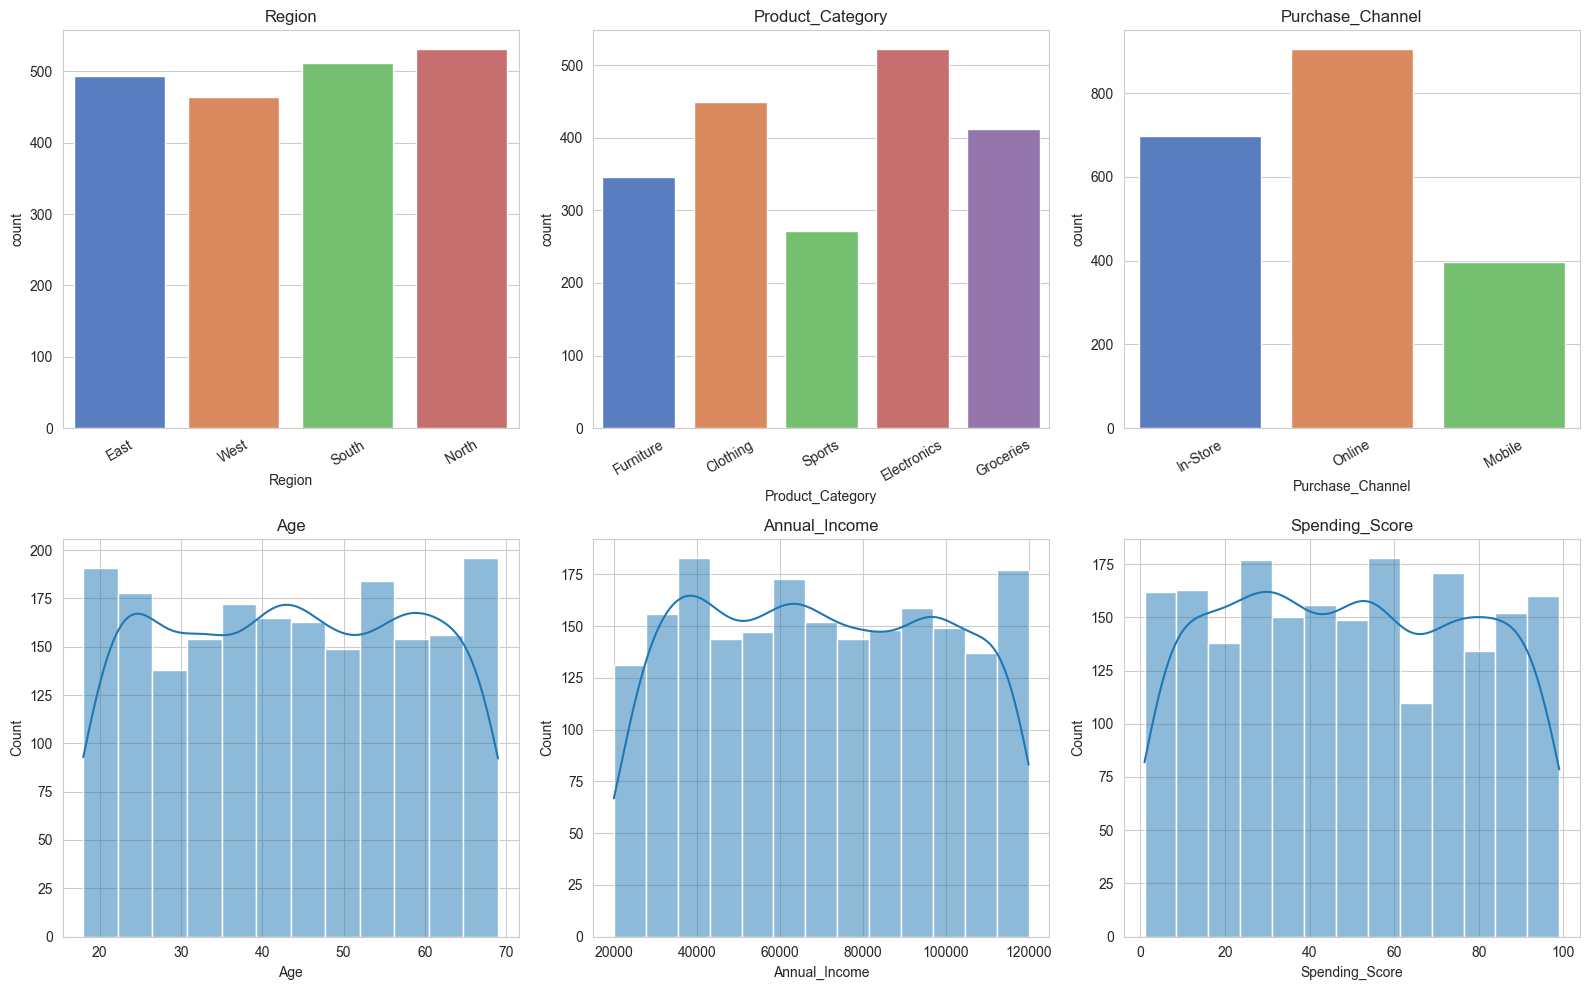

In [3]:
# 2. Exploratory Data Analysis

cat_cols = ['Region', 'Product_Category', 'Purchase_Channel']
num_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes[0], cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='muted')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
for ax, col in zip(axes[1], num_cols[:3]):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
     

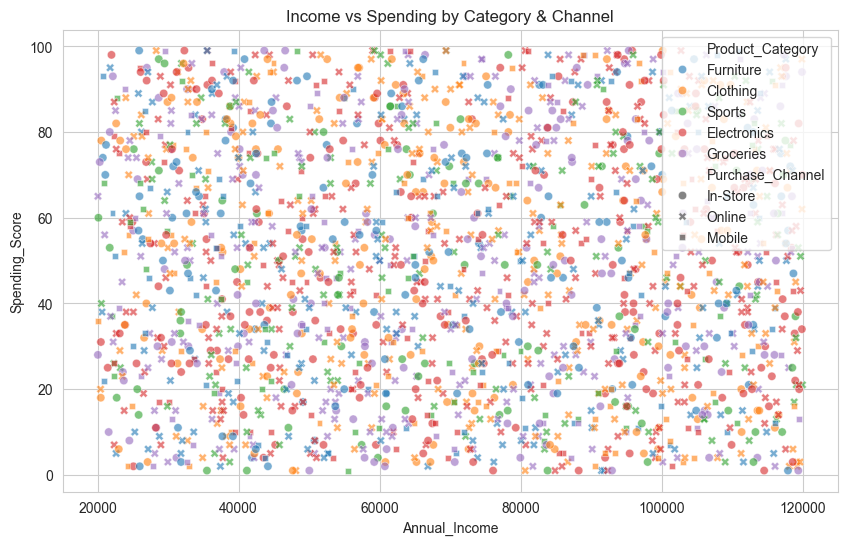

In [4]:
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Product_Category', style='Purchase_Channel', alpha=0.6)
plt.title('Income vs Spending by Category & Channel')
plt.show()
     


In [5]:
# 3. Prepare Mixed-Type Features

feature_cols = cat_cols + num_cols
df_model = df[feature_cols].copy()

# Scale numerical columns
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# Convert to mixed-type array: strings for categorical, floats for numerical
X_mixed = df_model.values
cat_indices = list(range(len(cat_cols)))

print(f'Feature order: {feature_cols}')
print(f'Categorical indices: {cat_indices}')
print(f'Matrix shape: {X_mixed.shape}')

Feature order: ['Region', 'Product_Category', 'Purchase_Channel', 'Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
Categorical indices: [0, 1, 2]
Matrix shape: (2000, 8)


K=2, Cost=10490.29
K=3, Cost=9551.92
K=4, Cost=8764.49
K=5, Cost=8171.24
K=6, Cost=7703.43
K=7, Cost=7352.35
K=8, Cost=7007.76


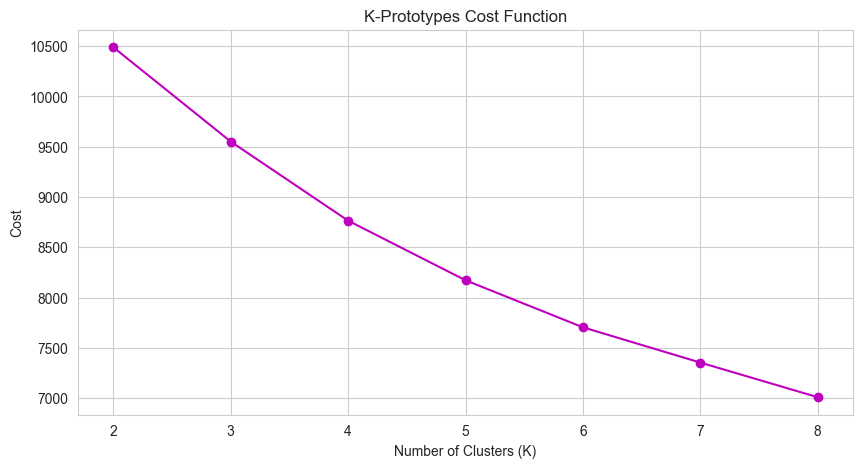

In [6]:
# 4. Find Optimal K (Cost Function)

k_range = range(2, 9)
costs = []

for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Huang', n_init=3, random_state=RANDOM_STATE, verbose=0)
    kp.fit(X_mixed, categorical=cat_indices)
    costs.append(kp.cost_)
    print(f'K={k}, Cost={kp.cost_:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, costs, 'mo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost')
plt.title('K-Prototypes Cost Function')
plt.show()

In [ ]:

# 5. Train Final K-Prototypes Model

OPTIMAL_K = 4
kproto = KPrototypes(n_clusters=OPTIMAL_K, init='Huang', n_init=10, random_state=RANDOM_STATE, verbose=0)
df['Cluster'] = kproto.fit_predict(X_mixed, categorical=cat_indices)

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nFinal Cost: {kproto.cost_:.2f}')

Cluster distribution:
Cluster
0    483
1    517
2    502
3    498
Name: count, dtype: int64

Final Cost: 8764.49


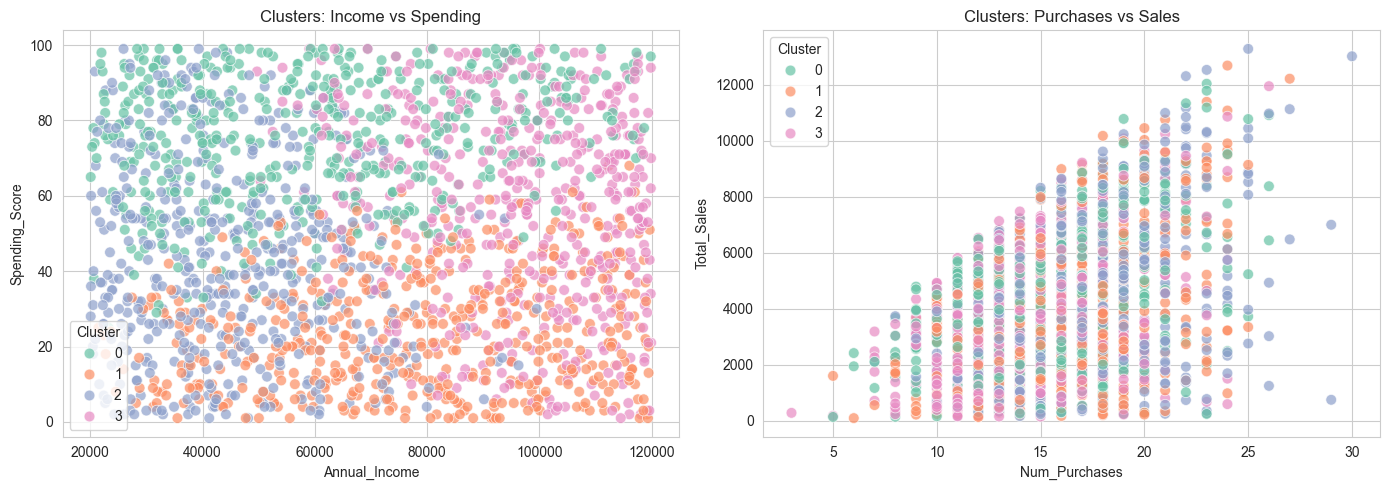

In [17]:
# 6. Visualize Clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='Set2', ax=axes[0], s=60, alpha=0.7)
axes[0].set_title('Clusters: Income vs Spending')
sns.scatterplot(data=df, x='Num_Purchases', y='Total_Sales', hue='Cluster', palette='Set2', ax=axes[1], s=60, alpha=0.7)
axes[1].set_title('Clusters: Purchases vs Sales')
plt.tight_layout()
plt.show()
     

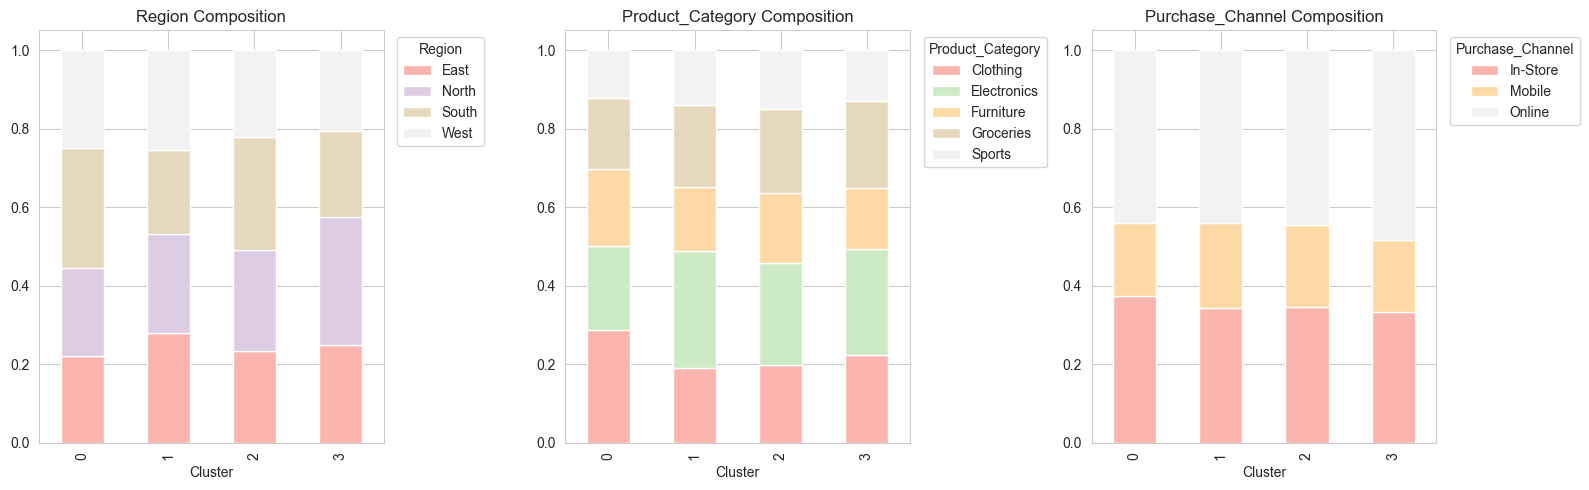

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df['Cluster'], df[col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Pastel1')
    ax.set_title(f'{col} Composition')
    ax.legend(title=col, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [19]:

# 7. Cluster Profiling

profile = df.groupby('Cluster').agg({
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Num_Purchases': 'mean',
    'Total_Sales': 'mean',
    'Region': lambda x: x.mode()[0],
    'Product_Category': lambda x: x.mode()[0],
    'Purchase_Channel': lambda x: x.mode()[0],
}).round(2)
profile.columns = ['Avg_Income', 'Avg_Spending', 'Avg_Purchases', 'Avg_Total_Sales', 'Top_Region', 'Top_Category', 'Top_Channel']
profile

,Avg_Income,Avg_Spending,Avg_Purchases,Avg_Total_Sales,Top_Region,Top_Category,Top_Channel
Cluster,,,,,,,
0,60896.47,75.67,15.81,4552.04,South,Clothing,Online
1,78371.79,23.75,16.16,3889.96,East,Electronics,Online
2,45051.73,42.97,17.18,4448.90,South,Electronics,Online
3,96229.65,57.25,14.64,3702.68,North,Electronics,Online


In [20]:
pd.crosstab(df['Cluster'], df['Customer_Segment'], normalize='index').round(3)
     

Customer_Segment,Budget,Premium,Regular,VIP
Cluster,,,,
0,0.008,0.526,0.290,0.176
1,0.166,0.221,0.607,0.006
2,0.259,0.161,0.580,0.000
3,0.000,0.542,0.173,0.285
